In [41]:
# Inference and visualization pipeline (single-frame + threaded video)
# Place this cell near the end of the notebook and run it to perform inference.
import cv2
import time
import math
import threading
import queue
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from PIL import Image

# Color map (BGR for OpenCV)
CLASS_COLORS = {
    0: (80, 80, 220),   # truck — red-ish in BGR
    1: (220, 160, 80),  # car   — blue-ish
    2: (120, 200, 80),  # van   — green-ish
    3: (50, 180, 240),  # bus   — amber-ish
}

DEFAULT_IMG_SIZE = 640


def letterbox(img, new_shape=(DEFAULT_IMG_SIZE, DEFAULT_IMG_SIZE), color=(114,114,114)):
    # Resize with unchanged aspect ratio using padding
    shape = img.shape[:2]  # h, w
    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    new_unpad = (int(round(shape[1] * r)), int(round(shape[0] * r)))
    dw = new_shape[1] - new_unpad[0]
    dh = new_shape[0] - new_unpad[1]
    dw /= 2
    dh /= 2
    resized = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return padded, r, (left, top)



def scale_coords(box, r, pad, orig_shape):
    # box = (x1,y1,x2,y2) in resized/padded coords → scale back to original image coords
    left, top = pad
    x1, y1, x2, y2 = box
    x1 = max(0, (x1 - left) / r)
    y1 = max(0, (y1 - top) / r)
    x2 = max(0, (x2 - left) / r)
    y2 = max(0, (y2 - top) / r)
    h, w = orig_shape
    x1 = min(w, x1); x2 = min(w, x2); y1 = min(h, y1); y2 = min(h, y2)
    return (int(x1), int(y1), int(x2), int(y2))



def iou_xyxy(a, b):
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1]); x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0



def nms_standard(detections, iou_thresh=0.45):
    # detections: list of (x1,y1,x2,y2,score,cls)
    if not detections:
        return []
    dets = np.array(detections)
    x1 = dets[:,0]; y1 = dets[:,1]; x2 = dets[:,2]; y2 = dets[:,3]; scores = dets[:,4]
    areas = (x2-x1)*(y2-y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        ovr = inter / (areas[i] + areas[order[1:]] - inter + 1e-8)
        inds = np.where(ovr <= iou_thresh)[0]
        order = order[inds + 1]
    return [tuple(detections[int(i)]) for i in keep]



def soft_nms(detections, sigma=0.5, score_thresh=0.001):
    # Gaussian Soft-NMS (class-agnostic). detections is list of tuples
    D = [list(d) for d in detections]
    keep = []
    while D:
        # pick highest score
        D.sort(key=lambda x: x[4], reverse=True)
        best = D.pop(0)
        keep.append(tuple(best))
        for i in range(len(D)):
            iou_v = iou_xyxy(best[:4], D[i][:4])
            D[i][4] = D[i][4] * math.exp(-(iou_v * iou_v) / sigma)
        D = [d for d in D if d[4] >= score_thresh]
    return keep



def post_process(preds, orig_shape, conf_thres=0.25, iou_thres=0.45, use_soft=False):
    # preds: list of (cls, score, (x1,y1,x2,y2)) per image
    dets = []
    for cls, score, box in preds:
        if score < conf_thres:
            continue
        x1,y1,x2,y2 = box
        dets.append((x1,y1,x2,y2,score,int(cls)))
    if use_soft:
        kept = soft_nms(dets, sigma=0.5, score_thresh=conf_thres)
    else:
        kept = nms_standard(dets, iou_thresh=iou_thres)
    out = [{'box': (int(d[0]),int(d[1]),int(d[2]),int(d[3])), 'score': float(d[4]), 'cls': int(d[5])} for d in kept]
    return out



def draw_detections(img, dets, class_names=None, fps=None):
    out = img.copy()
    overlay = out.copy()
    h, w = img.shape[:2]
    counts = {i:0 for i in range(len(class_names))} if class_names else {}
    for d in dets:
        cls = d['cls']; score = d['score']; x1,y1,x2,y2 = d['box']
        counts[cls] = counts.get(cls, 0) + 1
        color = CLASS_COLORS.get(cls, (200,200,200))
        # filled rectangle with alpha
        cv2.rectangle(overlay, (x1,y1), (x2,y2), color, -1)
        # border
        cv2.rectangle(out, (x1,y1), (x2,y2), color, 2)
        # label pill
        label = f"{class_names[cls] if class_names else cls} {score:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        pill_w = tw + 8; pill_h = th + 6
        pill_x1 = x1
        pill_y1 = max(0, y1 - pill_h - 4)
        cv2.rectangle(out, (pill_x1, pill_y1), (pill_x1 + pill_w, pill_y1 + pill_h), color, -1)
        cv2.putText(out, label, (pill_x1 + 4, pill_y1 + pill_h - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
    # blend overlay
    alpha = 0.15
    out = cv2.addWeighted(overlay, alpha, out, 1 - alpha, 0)
    # top-left counts
    counts_text = " ".join([f"{class_names[i]}:{counts.get(i,0)}" for i in range(len(class_names))])
    cv2.putText(out, counts_text, (8, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)
    # FPS bottom-left
    if fps is not None:
        cv2.putText(out, f"FPS: {fps:.1f}", (8, h-12), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)
    return out



def infer_frame(model, image, class_names, conf_thres=0.25, use_soft_nms=False, device='cpu'):
    # image: BGR uint8
    h0, w0 = image.shape[:2]
    img, r, pad = letterbox(image, new_shape=DEFAULT_IMG_SIZE)
    # convert to RGB for ultralytics
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # ensure CPU by default; pass device='cpu' when GPU not available
    res = model.predict(source=img_rgb, imgsz=DEFAULT_IMG_SIZE, device=device, conf=conf_thres, iou=0.45, verbose=False)
    preds = []
    r0 = res[0]
    if hasattr(r0, 'boxes') and r0.boxes is not None:
        for b in r0.boxes:
            # b.xyxy is a tensor-like with shape [1,4] or array
            try:
                box_coords = b.xyxy[0].cpu().numpy() if hasattr(b.xyxy, 'cpu') else np.array(b.xyxy[0])
            except Exception:
                box_coords = np.array(b.xyxy).reshape(-1)[:4]
            score = float(b.conf) if hasattr(b, 'conf') else 0.0
            cls = int(b.cls) if hasattr(b, 'cls') else 0
            x1,y1,x2,y2 = scale_coords(box_coords, r, pad, (h0, w0))
            preds.append((cls, score, (x1,y1,x2,y2)))
    dets = post_process(preds, (h0,w0), conf_thres=conf_thres, iou_thres=0.45, use_soft=use_soft_nms)
    return dets


# Threaded video inference utilities
class FrameReader(threading.Thread):
    def __init__(self, src, frame_queue, stop_event):
        super().__init__(daemon=True)
        self.cap = cv2.VideoCapture(str(src))
        self.q = frame_queue
        self.stop_event = stop_event

    def run(self):
        while not self.stop_event.is_set():
            ret, frame = self.cap.read()
            if not ret:
                self.stop_event.set()
                break
            try:
                self.q.put(frame, timeout=1)
            except queue.Full:
                continue
        self.cap.release()

class InferenceWorker(threading.Thread):
    def __init__(self, model, frame_queue, out_queue, class_names, stop_event, device='cpu'):
        super().__init__(daemon=True)
        self.model = model
        self.frame_q = frame_queue
        self.out_q = out_queue
        self.class_names = class_names
        self.stop_event = stop_event
        self.device = device

    def run(self):
        while not self.stop_event.is_set():
            try:
                frame = self.frame_q.get(timeout=1)
            except queue.Empty:
                continue
            t0 = time.time()
            dets = infer_frame(self.model, frame, self.class_names, device=self.device)
            t1 = time.time()
            fps = 1.0 / max(1e-6, (t1 - t0))
            vis = draw_detections(frame, dets, class_names=self.class_names, fps=fps)
            try:
                self.out_q.put((vis, dets), timeout=1)
            except queue.Full:
                continue


def run_video_inference(model, source, output_path, class_names, device='cpu'):
    """Processes video and saves to output_path without displaying a preview."""
    frame_q = queue.Queue(maxsize=8)
    out_q = queue.Queue(maxsize=8)
    stop_event = threading.Event()
    
    reader = FrameReader(source, frame_q, stop_event)
    worker = InferenceWorker(model, frame_q, out_q, class_names, stop_event, device=device)
    reader.start()
    worker.start()

    # Get video properties for the writer
    cap = cv2.VideoCapture(str(source))
    fps_in = cap.get(cv2.CAP_PROP_FPS) or 25.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_vid = cv2.VideoWriter(str(output_path), fourcc, fps_in, (w, h))

    print(f"Processing video: {source} -> {output_path}")
    
    try:
        while not stop_event.is_set() or not out_q.empty():
            try:
                # Increased timeout to ensure we don't drop the last frames
                vis, dets = out_q.get(timeout=3)
                out_vid.write(vis)
            except queue.Empty:
                if stop_event.is_set():
                    break
                continue
    finally:
        stop_event.set()
        reader.join(timeout=2)
        worker.join(timeout=2)
        out_vid.release()
        print("Processing complete. Video saved.")

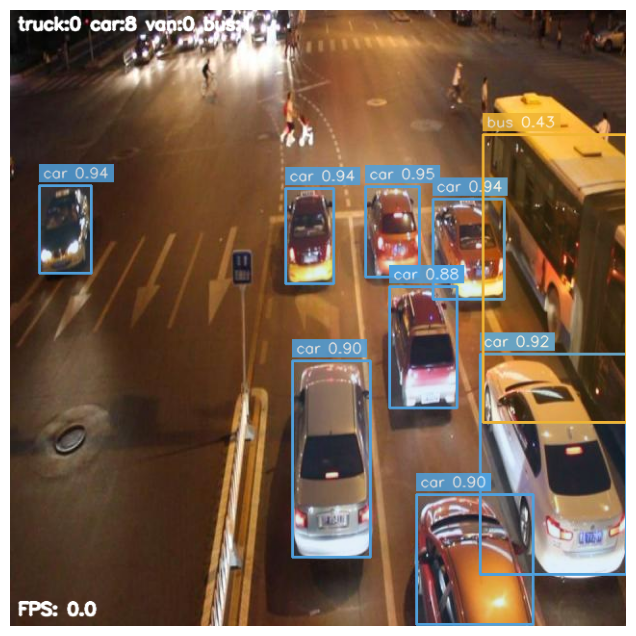

In [42]:
# For single-frame inference:
from ultralytics import YOLO

model = YOLO('/Users/lishanthan/Personal/College/SemVI/CV2/models/best_copy.pt') 
img = cv2.imread('/Users/lishanthan/Personal/College/SemVI/CV2/data/test/images/MVI_40772_img00512_jpg.rf.1ef38df85b41b93e8c732d22cc0f819c.jpg')
dets = infer_frame(model, img, ['truck','car','van','bus'])
vis = draw_detections(img, dets, class_names=['truck','car','van','bus'], fps=0.0)
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(vis_rgb)
plt.axis('off')  # Hide the x and y axis
plt.show()